<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
!تشخیص تقلب
</font>
</h1>

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معرفی مجموعه داده
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>

</font>
</p>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
در این قسمت کتاب‌خانه‌ها و ابزار مورد نیاز خود را <code>import</code> کنید و فایل داده‌ها را که در پوشه‌ی <code>Data</code> و که با نام‌های <code>train.csv</code> و <code>test.csv</code> ذخیره‌شده‌اند را بخوانید و وارد محیط کار خود کنید.
</font>
</p>

[Download file](https://quera.org/contest/assignments/84381/download_problem_initial_project/308147/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش‌پردازش و مهندسی ویژگی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
        در این سوال شما می‌توانید از هر تکنیک پیش‌پردازش/مهندسی ویژگی دلخواهتان، استفاده کنید.
    <br>
    تکنیک‌هایی که استفاده می‌کنید به شکل مستقیم مورد ارزیابی توسط سامانه داوری قرار <b>نمی‌گیرند.</b> بلکه همه آن‌ها در دقت مدل شما تاثیر خواهند گذاشت؛ بنابراین هر چه پیش‌پردازش/مهندسی ویژگی بهتری انجام دهید تا دقت مدل بهبود پیدا کند، امتیاز بیشتری از این سوال کسب خواهید کرد.
    در این قسمت شما می‌توانید بخشی از داده‌ی موجود را برای اعتبارسنجی در نظر بگیرید.
</font>
</p>

In [2]:
file_path = r"D:\uni and work\Competitions\Data no4\fraud-detection!\Data\train.csv"
file_path2 = r"D:\uni and work\Competitions\Data no4\fraud-detection!\Data\test.csv"

df_train = pd.read_csv(file_path)
df_test = pd.read_csv(file_path2)

df_train.head()

,timestamp,user_id,processing_batch_id,transaction_amount,user_age_days,ip_risk_score,transaction_speed_seconds,product_category,payment_method,is_fraud
0,29:50.2,104985,2113,4.27,392,30.01,17.73,subscription,credit_card,0
1,22:20.7,102534,2254,37.62,507,25.83,22.36,travel,debit_card,0
2,46:36.0,110534,2373,531.63,64,85.22,9.35,digital_service,credit_card,1
3,38:02.3,109236,2158,314.96,965,55.09,22.81,subscription,paypal,0
4,22:58.1,109706,2381,2300.59,45,94.31,4.67,digital_service,credit_card,1


In [3]:
df_train.shape

(9600, 10)

In [4]:
df_train = df_train.drop('user_id', axis=1)
df_train = df_train.drop('processing_batch_id', axis=1)

# Drop identifiers from test data (same as we did with train)
df_test = df_test.drop(['user_id', 'processing_batch_id'], axis=1)

print("Test data shape after dropping IDs:", df_test.shape)
print("\nTest columns now:")
print(df_test.columns.tolist())

Test data shape after dropping IDs: (2400, 7)

Test columns now:
['timestamp', 'transaction_amount', 'user_age_days', 'ip_risk_score', 'transaction_speed_seconds', 'product_category', 'payment_method']


In [5]:
df_train['is_fraud'].value_counts()

is_fraud
0    7104
1    2496
Name: count, dtype: int64

In [6]:
# Check data types and missing values
print("Training data info:")
print(df_train.info())
print("\nMissing values in training:")
print(df_train.isnull().sum())
print("\nTest data info:")
print(df_test.info())
print("\nMissing values in test:")
print(df_test.isnull().sum())

Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  9600 non-null   object 
 1   transaction_amount         9600 non-null   float64
 2   user_age_days              9600 non-null   int64  
 3   ip_risk_score              9600 non-null   float64
 4   transaction_speed_seconds  9600 non-null   float64
 5   product_category           9600 non-null   object 
 6   payment_method             9600 non-null   object 
 7   is_fraud                   9600 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 600.1+ KB
None

Missing values in training:
timestamp                    0
transaction_amount           0
user_age_days                0
ip_risk_score                0
transaction_speed_seconds    0
product_category             0
payment_method               0

In [7]:
# Examine timestamp format
print("Sample of timestamps:")
print(df_train['timestamp'].head(20))
print("\nTimestamp unique values count:", df_train['timestamp'].nunique())
print("\nTimestamp min and max values:")
print(df_train['timestamp'].min(), "to", df_train['timestamp'].max())

Sample of timestamps:
0     29:50.2
1     22:20.7
2     46:36.0
3     38:02.3
4     22:58.1
5     01:42.5
6     27:47.2
7     08:53.7
8     30:34.6
9     17:39.4
10    08:39.9
11    54:46.7
12    25:10.6
13    27:16.0
14    31:38.5
15    09:22.7
16    37:05.8
17    44:06.7
18    30:32.6
19    51:34.8
Name: timestamp, dtype: object

Timestamp unique values count: 8449

Timestamp min and max values:
00:00.1 to 59:58.9


In [8]:
# Explore categorical columns
print("Product categories in train:")
print(df_train['product_category'].value_counts())
print("\nPayment methods in train:")
print(df_train['payment_method'].value_counts())
print("\nProduct categories in test:")
print(df_test['product_category'].value_counts())
print("\nPayment methods in test:")
print(df_test['payment_method'].value_counts())

Product categories in train:
product_category
subscription       2643
digital_service    2160
travel             1636
apparel            1584
electronics        1577
Name: count, dtype: int64

Payment methods in train:
payment_method
credit_card    4350
paypal         2908
debit_card     2342
Name: count, dtype: int64

Product categories in test:
product_category
subscription       632
digital_service    526
travel             428
apparel            425
electronics        389
Name: count, dtype: int64

Payment methods in test:
payment_method
credit_card    1111
paypal          690
debit_card      599
Name: count, dtype: int64


In [9]:
def engineer_timestamp(df):
    """
    Convert timestamp string to numeric features.
    Logic: Split by colon, convert to total seconds.
    Example: '29:50.2' -> 29 minutes + 50.2 seconds = 1790.2 seconds
    """
    # Split timestamp into parts before and after colon
    timestamp_parts = df['timestamp'].str.split(':', expand=True)
    
    # Convert minutes and seconds to float
    minutes = timestamp_parts[0].astype(float)
    seconds = timestamp_parts[1].astype(float)
    
    # Create total seconds feature
    df['timestamp_seconds'] = minutes * 60 + seconds
    
    # Also keep individual components
    df['timestamp_minutes'] = minutes
    df['timestamp_sub_seconds'] = seconds
    
    return df

# Apply to both datasets
df_train = engineer_timestamp(df_train)
df_test = engineer_timestamp(df_test)

# Check the result
print("Original vs engineered timestamp:")
print(df_train[['timestamp', 'timestamp_seconds', 'timestamp_minutes', 'timestamp_sub_seconds']].head())

Original vs engineered timestamp:
  timestamp  timestamp_seconds  timestamp_minutes  timestamp_sub_seconds
0   29:50.2             1790.2               29.0                   50.2
1   22:20.7             1340.7               22.0                   20.7
2   46:36.0             2796.0               46.0                   36.0
3   38:02.3             2282.3               38.0                    2.3
4   22:58.1             1378.1               22.0                   58.1


In [10]:
from sklearn.preprocessing import LabelEncoder

def encode_categoricals(df_train, df_test):
    """
    Label encode categorical columns.
    Fit on training data, transform both train and test.
    """
    categorical_cols = ['product_category', 'payment_method']
    
    # Store encoders for each column
    encoders = {}
    
    for col in categorical_cols:
        encoder = LabelEncoder()
        
        # Fit on training data only
        encoder.fit(df_train[col])
        
        # Transform both datasets
        df_train[col + '_encoded'] = encoder.transform(df_train[col])
        df_test[col + '_encoded'] = encoder.transform(df_test[col])
        
        encoders[col] = encoder
        
        # Show mapping
        print(f"\n{col} mapping:")
        for i, category in enumerate(encoder.classes_):
            print(f"  {category} -> {i}")
    
    return df_train, df_test, encoders

df_train, df_test, encoders = encode_categoricals(df_train, df_test)


product_category mapping:
  apparel -> 0
  digital_service -> 1
  electronics -> 2
  subscription -> 3
  travel -> 4

payment_method mapping:
  credit_card -> 0
  debit_card -> 1
  paypal -> 2


In [11]:
# Define features we want to use
numeric_features = [
    'transaction_amount',
    'user_age_days', 
    'ip_risk_score',
    'transaction_speed_seconds',
    'timestamp_seconds',
    'timestamp_minutes',
    'timestamp_sub_seconds'
]

encoded_features = [
    'product_category_encoded',
    'payment_method_encoded'
]

# Combine all feature columns
feature_columns = numeric_features + encoded_features

# Prepare X and y for training
X = df_train[feature_columns].copy()
y = df_train['is_fraud'].copy()

# Prepare test data
X_test = df_test[feature_columns].copy()

print("Feature matrix shape:", X.shape)
print("Test matrix shape:", X_test.shape)
print("\nFeatures being used:")
print(X.columns.tolist())

Feature matrix shape: (9600, 9)
Test matrix shape: (2400, 9)

Features being used:
['transaction_amount', 'user_age_days', 'ip_risk_score', 'transaction_speed_seconds', 'timestamp_seconds', 'timestamp_minutes', 'timestamp_sub_seconds', 'product_category_encoded', 'payment_method_encoded']


In [12]:
from sklearn.model_selection import train_test_split

# Split with stratification to maintain fraud ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class balance
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("\nFraud ratio in training:", y_train.mean().round(3))
print("Fraud ratio in validation:", y_val.mean().round(3))
print("Overall fraud ratio:", y.mean().round(3))

Training set size: 7680
Validation set size: 1920

Fraud ratio in training: 0.26
Fraud ratio in validation: 0.26
Overall fraud ratio: 0.26


<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
آموزش مدل
</font>
</h2>



In [13]:
from sklearn.model_selection import train_test_split

# Split with stratification to maintain fraud ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class balance
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("\nFraud ratio in training:", y_train.mean().round(3))
print("Fraud ratio in validation:", y_val.mean().round(3))
print("Overall fraud ratio:", y.mean().round(3))

Training set size: 7680
Validation set size: 1920

Fraud ratio in training: 0.26
Fraud ratio in validation: 0.26
Overall fraud ratio: 0.26


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train basic model
rf_basic = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

# Train the model
rf_basic.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf_basic.predict(X_val)

# Calculate accuracy
val_acc = accuracy_score(y_val, y_val_pred)
print("=" * 50)
print("BASELINE RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Legitimate', 'Fraud']))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred)
print(f"                    Predicted Legitimate  Predicted Fraud")
print(f"Actual Legitimate          {cm[0,0]}                {cm[0,1]}")
print(f"Actual Fraud               {cm[1,0]}                {cm[1,1]}")

BASELINE RANDOM FOREST RESULTS
Validation Accuracy: 0.9958 (99.58%)

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      1421
       Fraud       0.98      1.00      0.99       499

    accuracy                           1.00      1920
   macro avg       0.99      1.00      0.99      1920
weighted avg       1.00      1.00      1.00      1920


Confusion Matrix:
                    Predicted Legitimate  Predicted Fraud
Actual Legitimate          1413                8
Actual Fraud               0                499


Feature Importance Rankings:
user_age_days                 : 0.4853
ip_risk_score                 : 0.2998
transaction_speed_seconds     : 0.0949
transaction_amount            : 0.0843
payment_method_encoded        : 0.0168
product_category_encoded      : 0.0101
timestamp_seconds             : 0.0033
timestamp_sub_seconds         : 0.0033
timestamp_minutes             : 0.0023


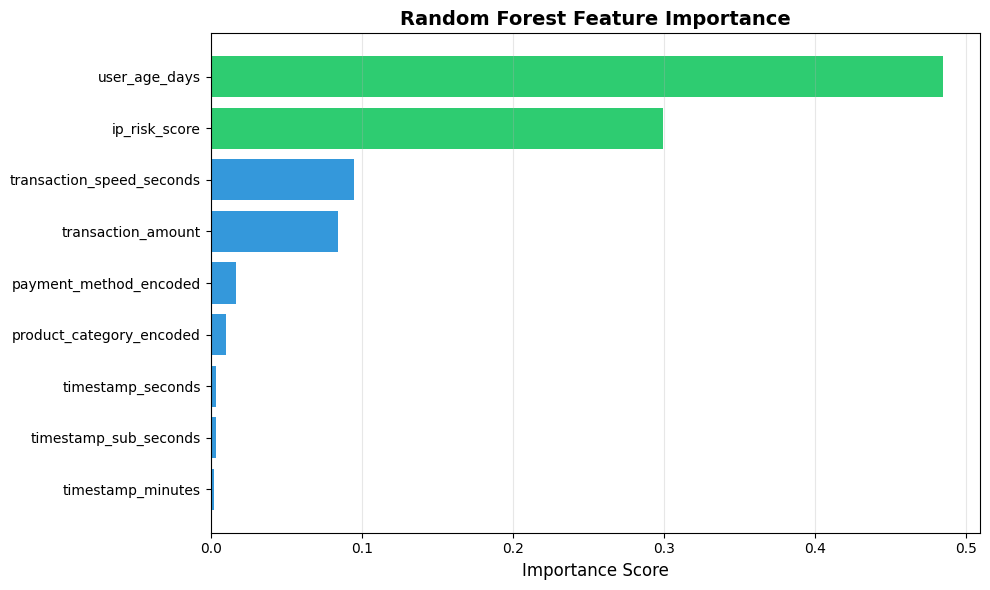

In [20]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_basic.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Rankings:")
print("=" * 40)
for i, row in importance_df.iterrows():
    print(f"{row['feature']:30s}: {row['importance']:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if imp > 0.1 else '#3498db' for imp in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>


In [21]:
# Train final model on ALL training data
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit on complete training data
final_model.fit(X, y)

# Predict on test data
test_predictions = final_model.predict(X_test)

# We need to get user_id from original test data
# Read test data again to get user_id
df_test_original = pd.read_csv(file_path2)
test_user_ids = df_test_original['user_id']

# Create submission with user_id and is_fraud
submission = pd.DataFrame({
    'user_id': test_user_ids,
    'is_fraud': test_predictions
})

print("Submission file created successfully!")
print(f"Shape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['is_fraud'].value_counts())
print(f"\nFirst few rows:")
print(submission.head(10))
print(f"\nLast few rows:")
print(submission.tail(10))

Submission file created successfully!
Shape: (2400, 2)

Prediction distribution:
is_fraud
0    1767
1     633
Name: count, dtype: int64

First few rows:
   user_id  is_fraud
0   100811         1
1   104345         1
2   100383         0
3   111014         0
4   110828         0
5   102660         0
6   105776         0
7   111588         0
8   109525         0
9   104805         0

Last few rows:
      user_id  is_fraud
2390   100698         0
2391   111320         0
2392   108439         0
2393   106225         0
2394   103394         0
2395   110834         0
2396   102130         1
2397   109608         0
2398   109950         0
2399   105078         0


<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) در غیر این صورت، در پایان مسابقه نمره شما به صفر تغییر خواهد کرد.
    <br>
    همچنین اگر از کولب برای اجرای این فایل نوت‌بوک استفاده می‌کنید، قبل از ارسال فایل <code>result.zip</code>، آخرین نسخه‌ی نوت‌بوک خود را دانلود کرده و داخل فایل ارسالی قرار دهید.
</font>

In [22]:
import zipfile
import joblib
import os

if not os.path.exists(os.path.join(os.getcwd(), 'fraudy.ipynb')):
    %notebook -e fraudy.ipynb

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
file_names = ['fraudy.ipynb', 'submission.csv']
compress(file_names)

File Paths:
['fraudy.ipynb', 'submission.csv']
